# TP Formation : créer une application

Nous utiliserons pour cet exercice, des données sur des céréales, leurs caractéristiques et leur notation
Nous construirons un package de projet nommé cereal_analysis

- Utiliser ce notebook pour alimenter le code du projet respectant les bonnes pratiques
    - Construire des fonctions, classes, modules, packages si nécéssaire
- Construire un script principal faisant appel à vos modules, pour produire les résultats (Fichiers Excel et HTML). Un exemple de contenu pour un fichier principal se trouve à la fin de ce Notebook
- Se placer dans le rép parent cible et construire un environnement virtuel de "Python 3.7", l'activer, puis y installer l'ensemble des packages nécéssaires avec: pip install -r requirement.txt 
- Lancer l'application:  Depuis un terminal, se placer dans le dépôt de l'appli et Exécuter la commande suivante: cereal-env CerealAnalysis (si cereal-env est l'env. créé!)

Application corrigée dans ce repository public : https://github.com/damiengarrouste78/CerealAnalysis-repo.git

# Architecture de l'application à envisager

Voici une organisation possible


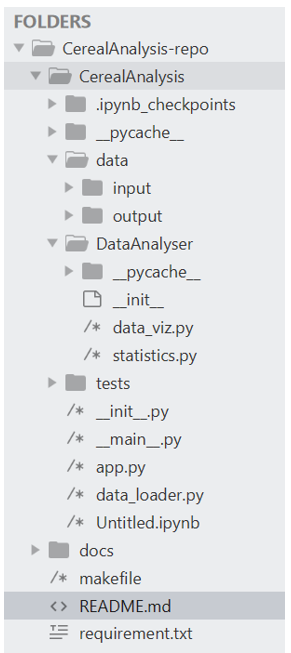

In [1]:
from IPython.display import Image
print("Voici une organisation possible")
Image(filename = "orga_projet.png")

# 0) Environnement

In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


# 1) Data Loader
Construire un module "Data Loader" en codant des fonction load_data et check_data

### Load Data
Charger le fichier cereal_data contenant quelques variétés de céréales ainsi que leurs charactéristiques

In [ ]:
df = pd.read_csv("cereal_data.csv", delimiter=';', decimal=".", encoding = 'utf-8')
df.head()

### Check Data
Vérifier si le fichier est conforme aux prérequis pour la suite de l'analyse

In [ ]:
# List of data columns
data_columns = list(df.columns)
print("Data columns: {}".format(data_columns))
print("\n")

# Load list of relevant columns
f = open("relevant_col.txt", "r")
loaded_relevant_col = f.read().split('\n')
f.close()
print("Relevant columns: {}".format(loaded_relevant_col))
print("\n")

# Check if our list of columns contains all relevant columns
list_columns = list(df.columns)
included =  all(elem in data_columns  for elem in loaded_relevant_col)
if included:
    print("Yes, data_columns contains all elements in loaded_relevant_col")
    variable_ok = True
else :
    print("No, data_columns does not contains all elements in loaded_relevant_col")
    variable_ok = False

# 2) Data Analyser

Construire un package "Data Analyser" contenant les deux modules suivants:
- statistics
- Visualisation

# 2-1) Statistics

### Global stats

In [ ]:
# var_num stats

var_num = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'rating']
cereal_desc_num =  df[var_num].describe()
cereal_desc_num["KPI"] =  cereal_desc_num.index
cereal_desc_num

In [ ]:
# var_cat stats

var_cat = ['mfr', 'type', 'shelf']
cereal_desc_cat =  df[var_cat].describe()
cereal_desc_cat["KPI"] =  cereal_desc_cat.index
cereal_desc_cat

### Specific Stats

In [ ]:
# Aggregations by fat

agg_fat = df.groupby(['fat'],as_index=False) \
.agg({'rating': ['mean', 'max'] \
      ,'sugars':'mean' \
      ,'carbo' :'mean' \
      ,'protein' :'mean'})

agg_fat

In [ ]:
# Aggregations by mfr

agg_mfr = df.groupby(['mfr'],as_index=False) \
.agg({'rating': ['mean', 'max']  \
      ,'sugars':'mean' \
      ,'fat' :'mean' \
      ,'carbo' :'mean'
      ,'protein' :'mean'})

agg_mfr

# 2-2) Visualization

In [ ]:
# Rating distribution

distribution_Rating = px.histogram(df, x='rating',  marginal="rug", title='Rating distribution')
distribution_Rating.show()


In [ ]:
# Relation entre rating and sugars

scatter_rating_sugars = px.scatter(df, x='sugars', y='rating', trendline="lowess", hover_name='name',
                                   title='Cereal ratings vs. sugars')
scatter_rating_sugars.show()

In [ ]:
# Relation entre rating et sugars en incluant les boxplots pour sugar et des violin pour rating
# présenter par shelt (en différentes couleurs)

scatter2_rating_sugars = px.scatter(df, x="sugars", y="rating", color="shelf", marginal_x="box", marginal_y="violin",
                                    title="Cereal ratings vs. sugars")

scatter2_rating_sugars.show()

In [ ]:
# Boxplots pour le rating, par mfr

box_rating = px.box(df, y="rating", points="all", color="mfr",  title="Box plot for rating, by mfr")

box_rating.show()

In [ ]:
# Un treemap pour illustrer la nature hiérarchique des données

treemap = px.treemap(df, path=['shelf', 'mfr'], values='cereal', title='Cereals by shelf location')
treemap.show()

#treemap.write_html('treemap.html', include_plotlyjs='cdn', full_html=False, include_mathjax='cdn')

In [ ]:
# Un Sunburst pour illustrer la nature hiérarchique des données

sunburst = px.sunburst(df, path=['shelf', 'mfr'], values='cereal', title='Cereals by shelf location')
sunburst.show()


In [ ]:
# Bubble chart pour rating et sugars

Bubble_rating_sugars = px.scatter(df,
                x='sugars',
                y='rating',
                color='mfr',
                size='calories',
                facet_row='shelf',
                #facet_col='type',
                hover_name='name',
                category_orders={'shelf': ['Top', 'Middle', 'Bottom']})
Bubble_rating_sugars.show()

# 3) Saving Results

In [ ]:
# Saving tables into excel files
cereal_desc_num.to_csv('cereal_desc_num.csv', sep=';', index=False, encoding='utf-8')
cereal_desc_cat.to_csv('cereal_desc_cat.csv', sep=';', index=False, encoding='utf-8')

agg_fat.to_csv('agg_fat.csv', sep=';', index=False, encoding='utf-8')
agg_mfr.to_csv('agg_mfr.csv', sep=';', index=False, encoding='utf-8')

In [ ]:
# Saving visualisation into unique html file
with open('cereal_reporting.html', 'a') as f:
    f.write(distribution_Rating.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(scatter_rating_sugars.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(scatter2_rating_sugars.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(box_rating.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(treemap.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(sunburst.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write(Bubble_rating_sugars.to_html(full_html=False, include_plotlyjs='cdn'))

# Exemple de fichier principal "app.py"

# Test de l'application

In [4]:
# se placer dans le répertoire parent de l'application
# créer un env virtuel appelé par exemple cereal-analysis
# un fichier requirements vous a été fourni, utilisez le pour installer les librairies nécessaires (plotly)

In [5]:
# lancer l'application depuis la ligne de commande